["# Policy Residual Analysis\n", "Evaluate the trained ONNX policy at every ground-truth trajectory state (zero tracking error).\n", "\n", "Compare the **nominal PD error** `joints_target[t] - joints[t]` (proportional to controller force)\n", "with the **corrected PD error** after adding the policy residual. If the policy widens the gap,\n", "it wants more force; if it shrinks it, the sim gains may be too high."]

In [1]:
import numpy as np
import yaml
import onnxruntime as ort
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

joint_names = ["shoulder_pan", "shoulder_lift", "elbow", "wrist_1", "wrist_2", "wrist_3"]

In [ ]:
def analyze_residual(run_dir, traj_path_override=None):
    """Evaluate the policy at each ground-truth trajectory step and plot per-joint PD error.

    At ground truth: relative_joint_pos = 0, relative_joint_vel = 0, only phase varies.

    Plots the nominal PD error (joints_target - joints) vs the corrected PD error
    (joints_target + residual - joints) to show whether the policy increases or
    decreases the effective force per joint.
    """
    run_dir = Path(run_dir)
    onnx_path = run_dir / "exported" / "policy.onnx"

    # Load env config
    with open(run_dir / "params" / "env.yaml") as f:
        env_cfg = yaml.unsafe_load(f)
    action_scale = env_cfg.get("action_scale", 0.05)
    kp = env_cfg.get("kp")
    kd = env_cfg.get("kd")

    # Load trajectory
    traj_path = traj_path_override or env_cfg["trajectory_path"]
    if not Path(traj_path).is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path
    traj = np.load(traj_path)
    joints_target = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    joints = traj["joints"] if "joints" in traj.files else traj["joints_l"]
    T = len(joints_target)

    # Load ONNX policy
    sess = ort.InferenceSession(str(onnx_path))
    input_name = sess.get_inputs()[0].name
    obs_dim = sess.get_inputs()[0].shape[1]

    # Evaluate at each ground-truth step
    actions = np.zeros((T, 6))
    for t in range(T):
        phase = t / (T - 1)
        obs = np.zeros((1, obs_dim), dtype=np.float32)
        obs[0, -1] = phase  # last element is phase
        out = sess.run(None, {input_name: obs})
        actions[t] = out[0][0, :6]

    residuals = action_scale * actions  # joint target offset in rad
    nominal_pd_error = joints_target - joints  # what the PD controller sees without policy
    corrected_pd_error = nominal_pd_error + residuals  # with policy correction
    time = np.arange(T) * 0.02  # 50 Hz

    title = run_dir.name
    print(f"{title}: {T} steps, action_scale={action_scale}, obs_dim={obs_dim}, kp={kp}, kd={kd}")
    print(f"Trajectory: {Path(traj_path).name}")

    # --- PD error: nominal vs corrected ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(time, nominal_pd_error[:, i], color='gray', alpha=0.7,
                label='nominal (joints_target - joints)')
        ax.plot(time, corrected_pd_error[:, i], color='tab:blue', alpha=0.8,
                label='corrected (+ residual)')
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('PD error (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel('time (s)')
    axes[-1, 1].set_xlabel('time (s)')
    fig.suptitle(f"PD error signal: nominal vs policy-corrected — {title}", fontsize=11)
    plt.tight_layout()

    # --- Residual direction: does the policy increase or decrease effective force? ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        amplifies = np.abs(corrected_pd_error[:, i]) > np.abs(nominal_pd_error[:, i])
        ax.fill_between(time, 0, residuals[:, i], where=amplifies,
                        color='tab:red', alpha=0.3, label='increases force (sim too soft)')
        ax.fill_between(time, 0, residuals[:, i], where=~amplifies,
                        color='tab:blue', alpha=0.3, label='decreases force (sim too stiff)')
        ax.plot(time, residuals[:, i], color='k', linewidth=0.8, alpha=0.7)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('residual (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel('time (s)')
    axes[-1, 1].set_xlabel('time (s)')
    fig.suptitle(f"Residual direction (red=sim too soft, blue=sim too stiff) — {title}", fontsize=11)
    plt.tight_layout()

    return residuals, nominal_pd_error

2026-04-12_12-46-08_cubic: 301 steps, action_scale=0.05, obs_dim=13
Trajectory: traj_full_20260412_114117_cubic.npz


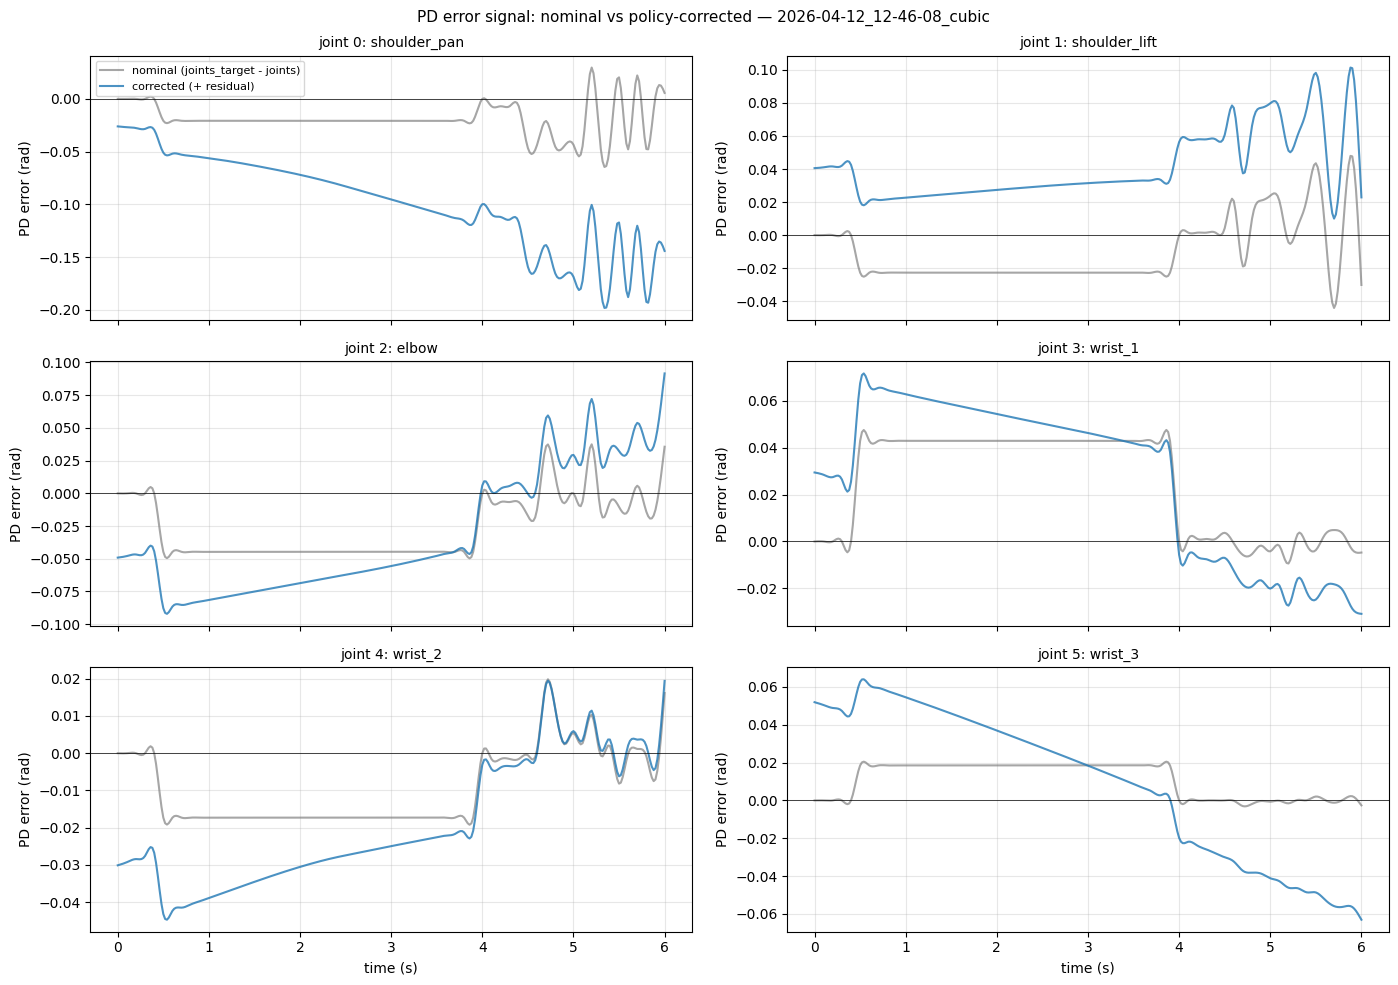

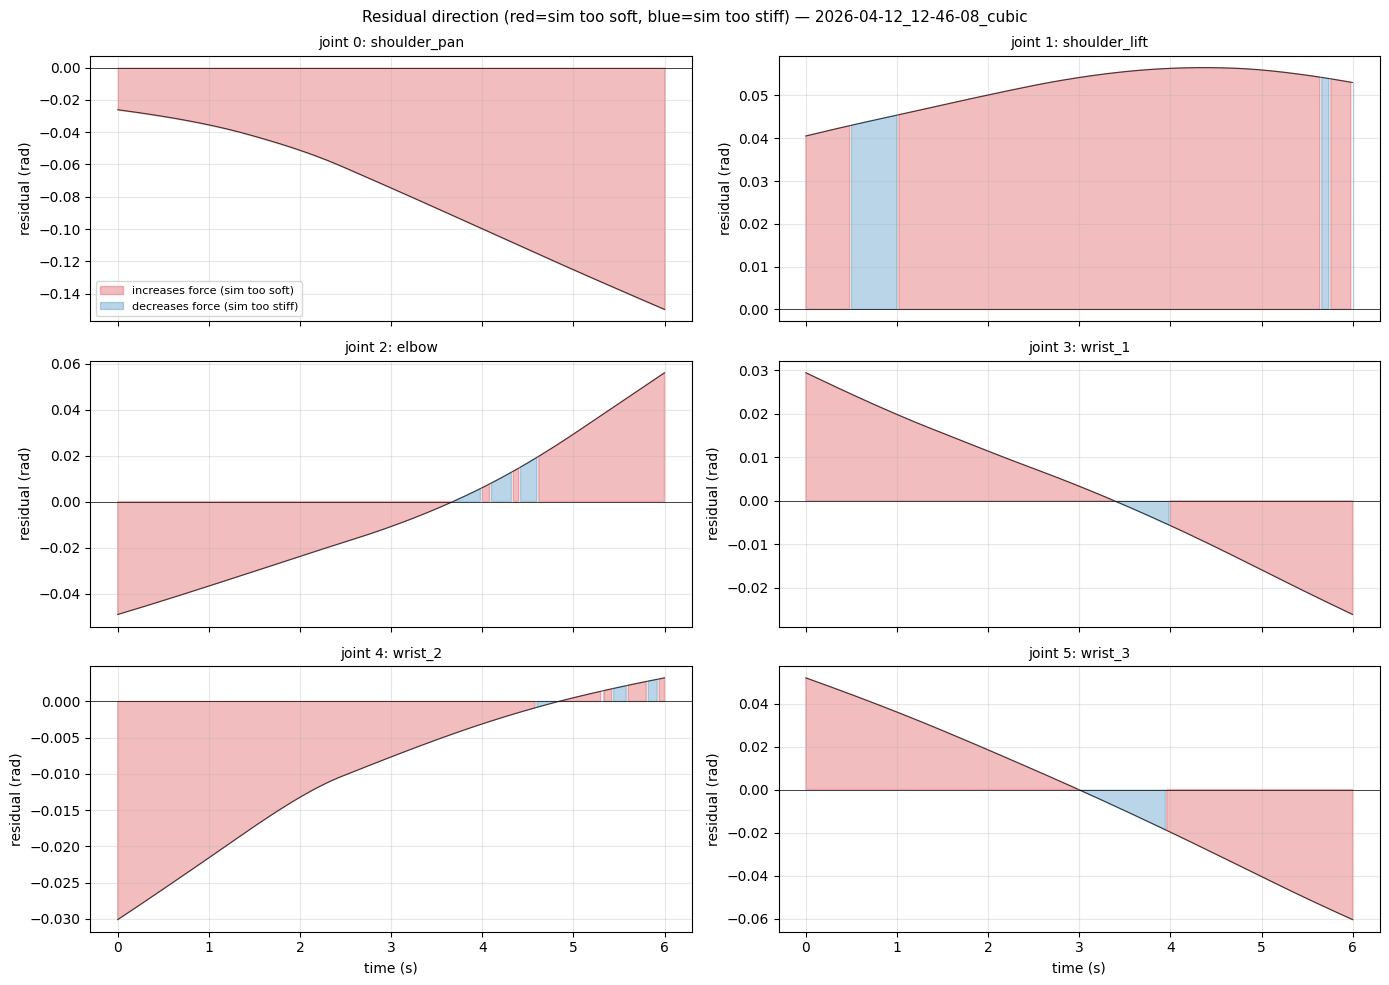

In [3]:
r = analyze_residual("../logs/rsl_rl/boxpush/2026-04-12_12-46-08_cubic")

In [ ]:
r = analyze_residual("../logs/rsl_rl/boxpush/2026-04-12_12-36-48_smoothed_gaussian_cubic")

In [ ]:
r = analyze_residual("../logs/rsl_rl/boxpush/2026-04-12_12-56-36_linear")

In [ ]:
r = analyze_residual("../logs/rsl_rl/boxpush/2026-04-12_13-05-44_smoothed_gaussian_linear")